In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as pltdf = pd.read_csv("Social_Network_Ads.csv")

In [ ]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [ ]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [ ]:
df.dtypes

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

In [ ]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [ ]:
# Create a LabelEncoder object
le = LabelEncoder()

# Apply label encoding to the 'Gender' column
df['Gender'] = le.fit_transform(df['Gender'])


In [ ]:
# Split the dataset into training and testing sets
train, test = train_test_split(df, test_size=0.3)  # Adjust test_size as needed (e.g., 0.3 for 30% test data)

# Split the training and testing sets into features (X) and target variable (y)
train_x, train_y = train.drop('Purchased', axis=1), train['Purchased']
test_x, test_y = test.drop('Purchased', axis=1), test['Purchased']

In [ ]:
# Create a MinMaxScaler object
sc = MinMaxScaler()

# Fit and transform the training set
train_x = sc.fit_transform(train_x)

# Transform the testing set (using the same scaler as the training set)
test_x = sc.transform(test_x)

In [ ]:
# Create a logistic regression model
lr = LogisticRegression()

# Train the model on the training data
lr.fit(train_x, train_y)

# Evaluate the model on the testing data
accuracy = lr.score(test_x, test_y)
print("Accuracy:", accuracy)

Accuracy: 0.85


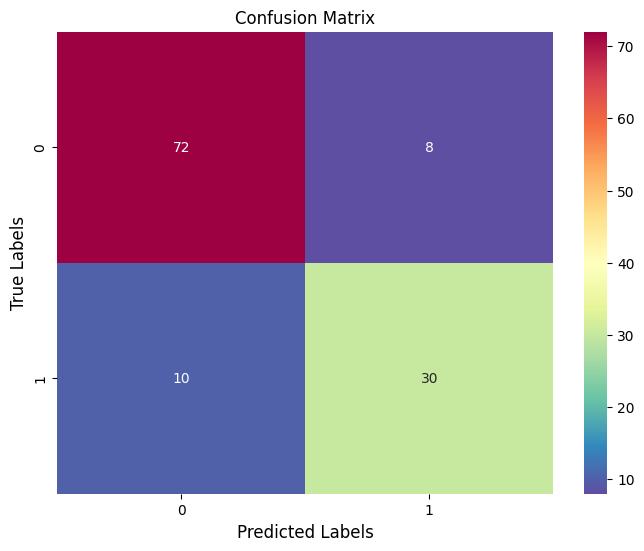

In [ ]:
# Predict labels for the test set
pred_y = lr.predict(test_x)

# Generate the confusion matrix
conf = confusion_matrix(test_y, pred_y)

# Plot the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf, cmap='Spectral_r', annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.ylabel('True Labels', size='large')
plt.xlabel('Predicted Labels', size='large')
plt.show()

In [ ]:
TP = conf[0][0]
TN = conf[1][1]
FP = conf[1][0]
FN = conf[0][1]

In [ ]:
# Accuracy
a = (TP + TN) / (TP + TN + FP + FN)
print("Accuracy:", a)

# Error Rate
error_rate = 1 - a
print("Error Rate:", error_rate)

# Precision
p = TP / (TP + FP)
print("Precision:", p)

# Recall
r = TP / (TP + FN)
print("Recall:", r)

# F1 Score
f1_score = 2 * p * r / (p + r)
print("F1 Score:", f1_score)

Accuracy: 0.85
Error Rate: 0.15000000000000002
Precision: 0.8780487804878049
Recall: 0.9
F1 Score: 0.888888888888889


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate accuracy score
accuracy = accuracy_score(test_y, pred_y)
print("Accuracy:", accuracy)
# Calculate Precision score
precision = precision_score(test_y, pred_y)
print("Precision:",precision )
# Calculate Precision score
recall = recall_score(test_y, pred_y)
print("Recall:",recall )
# Calculate Precision score
f1score = f1_score(test_y, pred_y)
print("F1 Score:",f1score )

Accuracy: 0.85
Precision: 0.7894736842105263
Recall: 0.75
F1 Score: 0.7692307692307692
